<a href="https://colab.research.google.com/github/djair7016-jpg/AdventureWorks-Analisis/blob/main/Copia_de_S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np # importar librerías

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [ ]:
# mostrar las primeras 5 filas de plans
print("=== PLANS - Primeras 5 filas ===")
print(plans.head())

=== PLANS - Primeras 5 filas ===
  plan_name  messages_included  gb_per_month  minutes_included  \
0    Basico                100             5               100   
1   Premium                500            20               600   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  
0               12         1.2             0.08            0.10  
1               25         1.0             0.05            0.07  


In [ ]:
# mostrar las primeras 5 filas de users
print("\n=== USERS - Primeras 5 filas ===")
print(users.head())


=== USERS - Primeras 5 filas ===
   user_id first_name last_name  age      city                       reg_date  \
0    10000     Carlos    Garcia   38  Medellín  2022-01-01 00:00:00.000000000   
1    10001      Mateo    Torres   53         ?  2022-01-01 06:34:17.914478619   
2    10002      Sofia   Ramirez   57      CDMX  2022-01-01 13:08:35.828957239   
3    10003      Mateo   Ramirez   69    Bogotá  2022-01-01 19:42:53.743435858   
4    10004      Mateo    Torres   63       GDL  2022-01-02 02:17:11.657914478   

      plan churn_date  
0   Basico        NaN  
1   Basico        NaN  
2   Basico        NaN  
3  Premium        NaN  
4   Basico        NaN  


In [ ]:
# mostrar las primeras 5 filas de usage
print("\n=== USAGE - Primeras 5 filas ===")
print(usage.head())


=== USAGE - Primeras 5 filas ===
   id  user_id  type                           date  duration  length
0   1    10332  call  2024-01-01 00:00:00.000000000      0.09     NaN
1   2    11458  text  2024-01-01 00:06:30.969774244       NaN    39.0
2   3    11777  text  2024-01-01 00:13:01.939548488       NaN    36.0
3   4    10682  call  2024-01-01 00:19:32.909322733      1.53     NaN
4   5    12742  call  2024-01-01 00:26:03.879096977      4.84     NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 260.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print("=== Cantidad de valores nulos en users ===")
print(users.isnull().sum()) # Cantidad de valores nulos
print("=== Proporción de valores nulos en users ===")
print(users.isnull().mean()) # Proporción de valores nulos

=== Cantidad de valores nulos en users ===
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
=== Proporción de valores nulos en users ===
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print("=== Cantidad de valores nulos en usage ===")
print(usage.isnull().sum()) # Cantidad de valores nulos
print("=== Proporción de valores nulos en usage ===")
print(usage.isnull().mean()) # Proporción de valores nulos

=== Cantidad de valores nulos en usage ===
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
=== Proporción de valores nulos en usage ===
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
    R= En el dataset "users" existen dos columnas con nulos:
  ° city: 469 valores nulos (11.73%)
  ° churn_date: 3,534 valores nulos (88.35%)
    Respecto al dataset "usage" existen tres columnas con nulos:
  ° date: 50 valores nulos (0.125%)
  ° duration: 22,076 valores nulos (55.19%)
  ° lenght: 17,896 valores nulos (44.74%)
  
- Indica qué harías: ¿imputar, eliminar, ignorar?
  Recomendaciones:
  ° city (11.73%): Imputar o mantener. Justificación: Por ser un porcentaje moderado se podría imputar como "Desconocido" o la ciudad más frecuente, o de igual forma, mantener los nulos si no afecta el análisis principal.
  ° churn_date (88.35%): Ignorar o mantener. Justificación: Dado que los nulos son estructuralemnte correctos representan usuarios que NO han abandonado el servicio. Muy probablemente se trate de información válida en lugar de datos faltantes.
  ° date (0.125%): Eliminar. Justificación: por ser un porcentaje bajo y por que la fecha es crucial para el análisis temporal.
  ° duration (55.19%) y lenght (44.74%): Ignorar o mantener. Justificación: Se trata de MAR (Missing At Random), "duration" es nulo para mensajes de texto, mientras que "lenght" es nulo para llamadas. Son nulos estructurales válidos.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
print("=== Resumen estadístico de USERS ===")
print(users.describe())

=== Resumen estadístico de USERS ===
            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` presenta un rango de 10,000 a 13,999 con distribución
secuencial normal. No se detectan duplicados ni valores inválidos.
Es una clave primaria válida para identificar usuarios únicos.
- La columna `age` presenta un valor negativo (-999) lo cual es imposible para la edad de una persona, esto es un clasico valor sentinel. Se debe identificar cuantos registros existen con ese valor y posteriomente reemplazar con un valor apropiado.

In [ ]:
# explorar columnas numéricas de usage
print("=== Resumen estadístico de USAGE ===")
print(usage.describe())

=== Resumen estadístico de USAGE ===
                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id`ambas columnas tienen exactamente 40,000 registros, dentro de los cuales demuestra que los valores máximos son idénticos (40,000 y 13,399 respectivamente) lo cual sugiere que son identificacdores únicos, no variables de análisis.
  
- La columna duration (duración de llamadas) demuestra valores interesantes. Como valores mínimos tenemos 0.0 es decir, ¿llamadas sin duración?, esto puede ser indicio de la existencia de llamadas perdidas o errores de registro. Valor máximo de 120.0 el cual parece ser un límite artificial, posiblemente un tope del sistema y respecto a la media (5.2 minutos) y la mediana (3.5 minutos) nos demuestra que existe una distribución sesgada a la derecha.


- Por su parte la columna lenght (longitud de mensajes) nos demuestra la existencia de valor mínimo de 0.0 es decir, la existencia de mensajes vacíos? Esto es técnicamente posible pero inusual, por su parte el valor máximo es de 1490.0 es decir, muy alto para un mensaje, indica la presencia de un outlier.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"\n=== Valores únicos en {col} ===")
    print(users[col].value_counts(dropna=False))


=== Valores únicos en city ===
city
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: count, dtype: int64

=== Valores únicos en plan ===
plan
Basico     2595
Premium    1405
Name: count, dtype: int64


- La columna `city` demuestra una distribución geográfica clara en la cual los datos muesran usuarios de ciudades principales de México y Colombia, lo cual es consistente con las operaciones de ConnectaTel en estos países.
Se demuestra que Bogotá lidera con 808 usuarios (mayor concentración) a comparación con las demás ciudades, sin embargo, se detectaron valores faltantes como: 96 registros con "?" en la columna city esto parece ser un valor centinela para datos faltantes y
469 valores NaN valores faltantes explícitos.
  
- La columna `plan` cuenta con solo 2 tipos de planes: Básico (2595 usuarios) y Premium (1405 usuarios).
Una distribución: Aproximadamente 65% Básico vs 35% Premium. Dado esta diferencia, sería efectivo considerar reducir el precio del plan Premium para así generar un mayor ingreso por usuario y mejor aprovechamiento en infraestructura. Y por otro lado, darle más enfoque al plan básico que es la preferencia natural del mercado actual.
Sin valores faltantes en esta columna.

In [ ]:
# explorar columna categórica de usage
usage['type'].value_counts() # completa el código

,count
type,
text,22092
call,17908


- La columna `type` demostró una relación con los valores nulos existentes.
- Patrón de comunicación equilibrado:
Se demostró un patrón de comunicación balanceado demostrando que los clientes se inclinan más por mensajes que por llamadas.
-Conexión con valores nulos:
Asimismo, los valores nulos demostrados tiene lógica ahora. Los 22,076 nulos en duration (55.19%) coinciden aproximadamente con los 22,092 de mensajes de texto y
los 17,896 nulos en length (44.74%) coinciden aproximadamente con los 17,908 llamadas.
- Validación de estructura de datos:
Se demostró que los nulos son estructuralmente correctos (MAR - Missing At Random), los mensajes NO tienen duración, es nulo y las llamadas NO tienen longitud de caracteres, es nulo de igual forma.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
  En el dataset "users" encontramos valores sentinels "?" en la columna 'city' siendo 96 registros representando el 2.4% del dataset, por su parte, en el dataset "usage" no encontramos como tal valores inválidos o sentinels, solo valores válidos en las columna 'type'.
- ¿Qué acción tomarías?
  Para los sentinels en la columna 'city' se me hace efectivo primeramente convertir los sentinels a nulos (NaN), porque no sabemos si son un problema para el análisis posterior, de esa forma podemos tomar una decisión más efectiva. A parte, al ser un porcentaje muy pequeño del dataset (2.4% de un 100%) no causa un efecto cuantitativo estratosferico para el análisis posterior.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')# completa el código

In [ ]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts().sort_index())

reg_date
2022    1314
2023    1316
2024    1330
2026      40
Name: count, dtype: int64


En `reg_date` se presentan 40 registros con fecha de 2026, lo cual es imposible por estamos en el año 2024, se presenta una cantidad de fechas de registros futuras, mismas que pueden sesgar en análisis de datos. Es necesario calcular el porcentaje de estos registros problemáticos del total.

In [ ]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts().sort_index())

date
2024.0    39950
Name: count, dtype: int64


En `date`, se presentan valores consistentes y válidos. Tiene los registros correspondientes al año 2024, sin la presencia de fechas imposibles o futuras. Existe una caliad coherente de rergistros con fecha válida (39,950 de 40,000 registros en total, existían 50 valores nulos).

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
R= En el dataset 'users' se establece la existencia de fechas futuras (2026) con estadística de 40 registros (bajo porcentaje, pero puede ocasionar confusión en el análisis).
- ¿Qué harías con ellas?
R= En este caso dado que son valores pequeños (40) deben ser un porcentaje menor del 7% probablemente, pero al ser fechas futuras podrían causar confusión en el análisis posterior. La opción más idónea desde mi perspectiva es convertirlos a NaNs, porque así podemos conservar la integridad y registro de los usuarios, evitamos sesgos, marca los datos problemáticos y podemos preparar un análisis más efectivo en las siguientes etapas.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users[users['age'] != -999]['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

,age
count,4000.000000
mean,48.136000
std,17.689919
min,18.000000
25%,33.000000
50%,48.000000
75%,63.000000
max,79.000000


In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print("=== Valores únicos en city después del cambio ===")
print(users['city'].value_counts(dropna=False))

=== Valores únicos en city después del cambio ===
city
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
<NA>         96
Name: count, dtype: int64


In [ ]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = users['reg_date'].where(users['reg_date'].dt.year <= 2024, pd.NaT)

# Verificar cambios
print("=== Distribución de años después del cambio ===")
print(users['reg_date'].dt.year.value_counts().sort_index())
print(f"\nTotal de valores NaT: {users['reg_date'].isna().sum()}")

=== Distribución de años después del cambio ===
reg_date
2022.0    1314
2023.0    1316
2024.0    1330
Name: count, dtype: int64

Total de valores NaT: 40


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
print("=== Verificación MAR para duration ===")
print("Nulos en duration por tipo de comunicación:")
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().sum()))
print("\nTotal de registros por tipo:")
print(usage['type'].value_counts())

=== Verificación MAR para duration ===
Nulos en duration por tipo de comunicación:
type
call        0
text    22076
Name: duration, dtype: int64

Total de registros por tipo:
type
text    22092
call    17908
Name: count, dtype: int64


In [ ]:
# Verificación MAR en usage (Missing At Random) para length
print("=== Verificación MAR para length ===")
print("Nulos en length por tipo de comunicación:")
print(usage.groupby('type')['length'].apply(lambda x: x.isna().sum()))
print("\nTotal de registros por tipo:")
print(usage['type'].value_counts())

=== Verificación MAR para length ===
Nulos en length por tipo de comunicación:
type
call    17896
text        0
Name: length, dtype: int64

Total de registros por tipo:
type
text    22092
call    17908
Name: count, dtype: int64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`.
La columna 'duration' demuestra que la mayoría de los clientes tienen una preferencia por el uso de mensajes de texto que de llamadas, de igual forma, estadísticamente nos demuestra que el total de mensajes es de 22,092 mensajes, los nulos en duration es de 22,076 lo cual demuestra que solo existe una diferencia de 16 registros entre ambas.

Por su parte la columna 'lenght' demuestra que la cantidad de valores nulos en esta columna dan un total de 17,896 de un total de 17,908 llamadas, por su parte, los mensajes de texto conservan una escasez de valores nulos con cero en 'lenght' de un total de 22,092 mensajes. Es decir, los valores nulos en 'lenght' son correctos dado que las llamadas telefónicas no tienen longitud de caractéres solo tiene duración y los mensajes de texto es todo lo contrario, cuentan con longitud pero carecen de duración.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',           # Total de mensajes
    'is_call': 'sum',           # Total de llamadas
    'duration': 'sum'           # Total de minutos de llamadas
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,reg_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3960,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.136000,2023-07-03 21:39:41.095273728,5.524381,4.478120,23.317054
min,10000.000000,18.000000,2022-01-01 00:00:00,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,2022-10-02 20:17:11.657914368,4.000000,3.000000,11.120000
50%,11999.500000,48.000000,2023-07-04 10:00:05.401350400,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,2024-04-03 04:00:05.401350400,7.000000,6.000000,31.415000
max,13999.000000,79.000000,2024-12-31 00:00:00,17.000000,15.000000,155.690000
std,1154.844867,17.689919,NaN,2.358416,2.144238,18.168095


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

,proportion
plan,
Basico,64.875
Premium,35.125


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

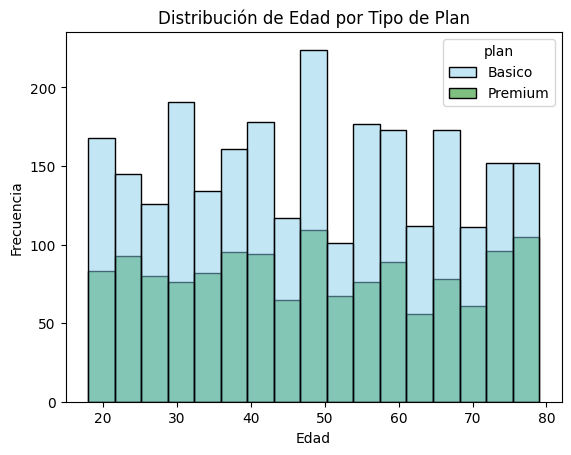

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
1. Distribución general de edad:
- La mayoría de usuarios están entre 20-70 años.
- Hay un pico notable alrededor de los 45-50 años.

2. Diferencias por tipo de plan:
- Los usuarios del plan Básico (azul) son consistentemente más numerosos en casi todos los grupos de edad.
- Los usuarios del plan Premium (verde) representan una proporción menor pero constante.

3. Patrones por edad:
- En edades más jóvenes (20-30), la diferencia entre planes es menor.
- En el grupo de 45-50 años, la diferencia se hace más pronunciada.

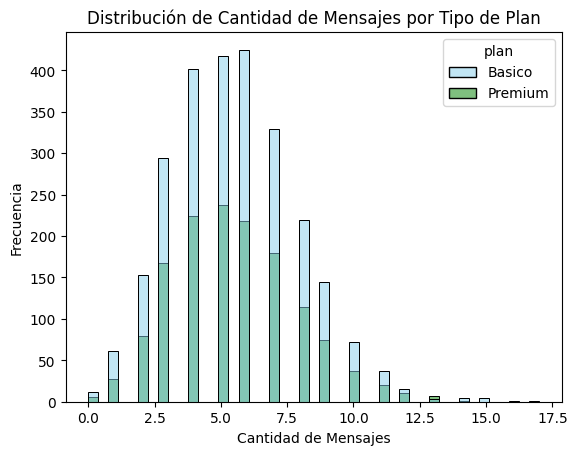

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de Cantidad de Mensajes por Tipo de Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
1. Distribución general:

La distribución está sesgada hacia la derecha, con la mayoría de usuarios enviando entre 4-7 mensajes.
El pico más alto está alrededor de 5-6 mensajes por usuario.

2. Diferencias por tipo de plan:

Los usuarios del plan Básico (azul) dominan en casi todos los rangos de cantidad de mensajes.
Los usuarios Premium (verde) mantienen un patrón similar pero en menor volumen.
No hay una diferencia dramática en el comportamiento de mensajería entre planes.

3. Patrones específicos:

Muy pocos usuarios envían 0 mensajes (casi todos usan la función de mensajería).
Los usuarios que envían más de 10 mensajes son relativamente pocos (outliers).
La mayoría se concentra en el rango de 3-8 mensajes.

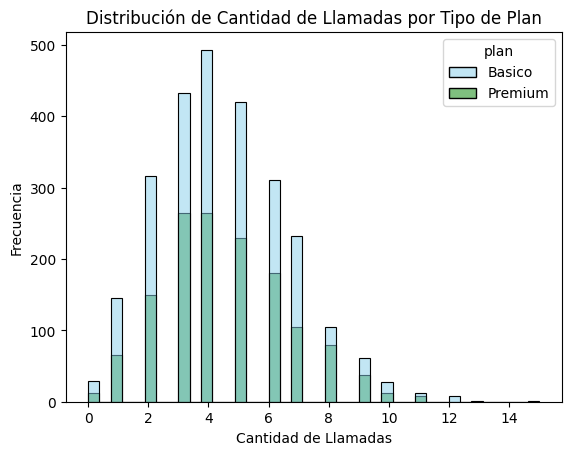

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de Cantidad de Llamadas por Tipo de Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
1. Distribución general:

La distribución tiene forma de campana con un pico claro alrededor de 4-5 llamadas.
Es más simétrica que la distribución de mensajes.
La mayoría de usuarios hace entre 2-8 llamadas.

2. Diferencias por tipo de plan:

Los usuarios del plan Básico (azul) siguen siendo mayoría en todos los rangos.
Los usuarios Premium (verde) mantienen una proporción constante pero menor.
Patrón similar entre ambos planes - no hay diferencias dramáticas en comportamiento.

3. Comportamientos específicos:

Muy pocos usuarios hacen 0 llamadas (casi todos usan esta función).
Los usuarios que hacen más de 10 llamadas son casos excepcionales.
El rango más común es 3-6 llamadas por usuario.

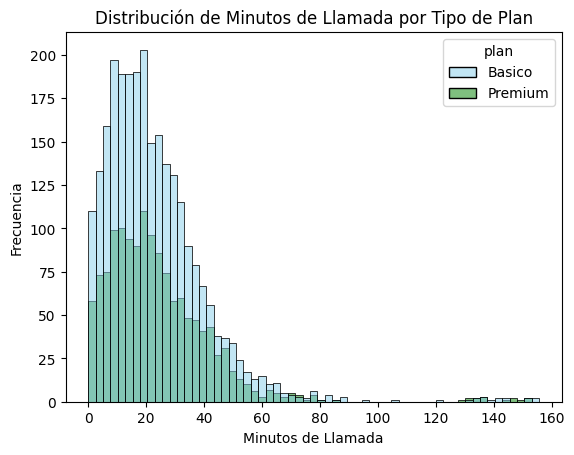

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de Minutos de Llamada por Tipo de Plan')
plt.xlabel('Minutos de Llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
- Los usuarios del plan Básico (azul) muestran una distribución más concentrada en valores bajos de minutos.
Los usuarios del plan Premium (verde) tienen una distribución más extendida hacia valores más altos.
En otras palabra:
Podemos ver la existencia de un sesgo hacia la derecha lo cual nos indica que existen pocos valores muy altos que empujan el valor de la media, demostrando que la mediana es más confiable. Asimismo, nos muestra que la duración de las llamadas no es tan extensa como creeríamos, en concreto es de 20 a 40 minutos aproximadamente, siendo los clientes del plan "básico" los que aportan más. Los premium se quedan bastante abajo, puede ser por cuestiones de larga distancía, precio, conectividad, o algún otro.
Para mejorar el plan premium es necesario un analisis comparativo de ambos planes, con ello podríamos revisar que hace mejor el plan "básico" y en caso dado, incorporar esas mejoras al plan "premium" sin alterrar su costo, pero si podemos ampliar el uso de la red y conectividad, posiblemente con ello mejoraríamos la satisfacción del cliente y tendriamos mejores resultados para la empresa.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

/tmp/ipykernel_5178/2622626350.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=user_profile, y=col, palette=['lightblue'])


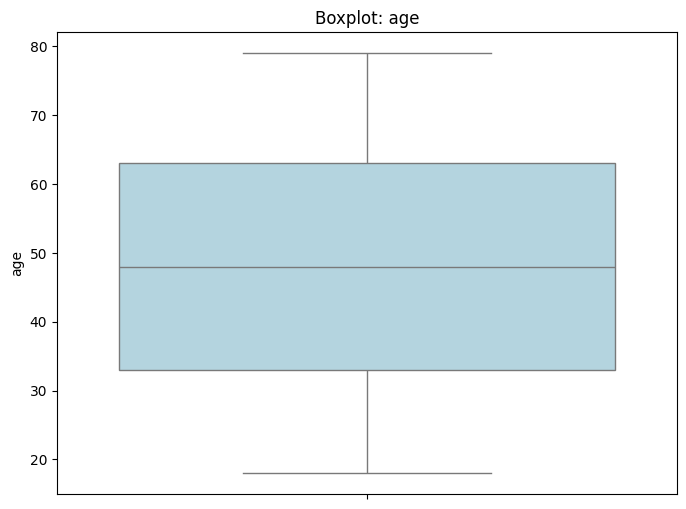

/tmp/ipykernel_5178/2622626350.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=user_profile, y=col, palette=['lightblue'])


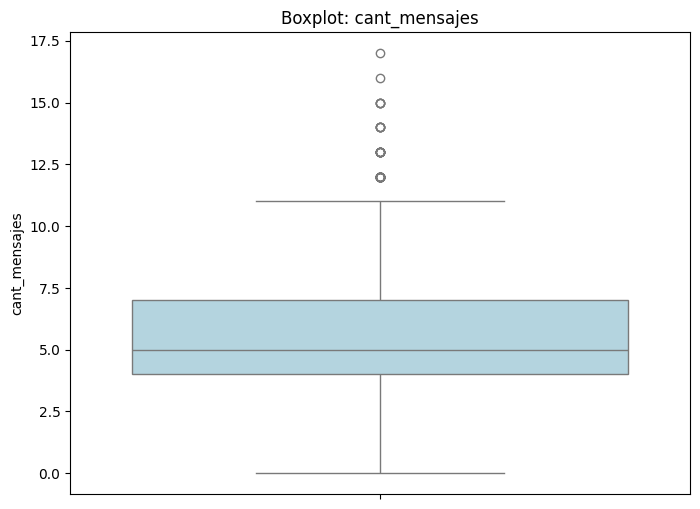

/tmp/ipykernel_5178/2622626350.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=user_profile, y=col, palette=['lightblue'])


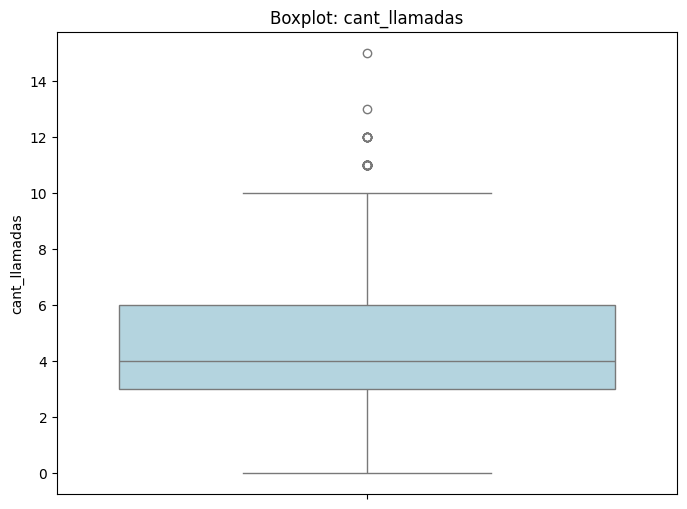

/tmp/ipykernel_5178/2622626350.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=user_profile, y=col, palette=['lightblue'])


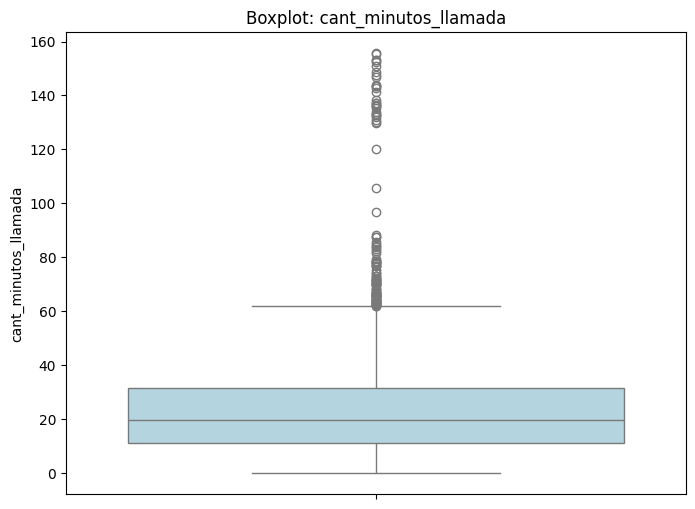

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=user_profile, y=col, palette=['lightblue'])
    plt.title(f'Boxplot: {col}')
    plt.ylabel(col)
    plt.show()

💡Insights:
- Age: No presenta outliers. Todos los datos están contenidos dentro del rango normal del boxplot.
- cant_mensajes: No presenta outliers. La distribución está contendia dentro de los límites del boxplot.
- cant_llamadas: Presenta un outlier extremo. Se observan 4 puntos por encima del bigote superior.
- Estos representan usuarios con un número de llamadas significativamente mayor al patrón normal.
- Los valores outliers están aproximadamente en: 11, 12, 13 y 15 llamadas.
- cant_minutos_llamada: Presenta un outlier de caractér leve.
- Hay outliers presentes: Los puntos que aparecen por encima del bigote superior del boxplot indican valores atípicos.
Son menos extremos
Distribución sesgada: La caja está más concentrada en valores bajos, con una cola larga hacia la derecha.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_llamadas', 'cant_minutos_llamada', 'cant_mensajes']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    print(f"{col}:")
    print(f"  Límite inferior: {limite_inferior:.2f}")
    print(f"  Límite superior: {limite_superior:.2f}")
    print(f"  Valores máximos: {user_profile[col].max():.2f}")
    print()

cant_llamadas:
  Límite inferior: -1.50
  Límite superior: 10.50
  Valores máximos: 15.00

cant_minutos_llamada:
  Límite inferior: -19.32
  Límite superior: 61.86
  Valores máximos: 155.69

cant_mensajes:
  Límite inferior: -0.50
  Límite superior: 11.50
  Valores máximos: 17.00



In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_llamadas,cant_minutos_llamada,cant_mensajes
count,3999.000000,3999.000000,3999.000000
mean,4.478120,23.317054,5.524381
std,2.144238,18.168095,2.358416
min,0.000000,0.000000,0.000000
25%,3.000000,11.120000,4.000000
50%,4.000000,19.780000,5.000000
75%,6.000000,31.415000,7.000000
max,15.000000,155.690000,17.000000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué? R= Mantenerlos. Justificación:
Límite superior IQR: 10.50 | Máximo real: 17.00
- Diferencia mínima: Solo 6.5 mensajes por encima del límite
- Uso normal: 17 mensajes es un volumen completamente normal
- Sin impacto negativo: Estos valores no distorsionan el análisis
- Representan diversidad: Muestran la variabilidad natural en patrones de comunicación

- cant_llamadas: mantener o no outliers, porqué? R= Mantener. Justificación:
Límite superior IQR: 10.50 | Máximo real: 15.00
- Diferencia moderada: Solo 4.5 llamadas por encima del límite
- Comportamiento realista: 15 llamadas por período es perfectamente posible para usuarios activos
- Valor comercial: Estos usuarios representan el segmento de "heavy users" más valioso para ConnectaTel
- No son errores: Los valores están dentro de rangos lógicos de uso
  
- cant_minutos_llamada: mantener o no outliers, porqué? R= Mantenerlos.
Límite superior IQR: 61.86 | Máximo real: 155.69
Justificación:
- Uso intensivo válido: 155 minutos (2.6 horas) es factible en el período analizado.
- Clientes premium potenciales: Usuarios que podrían necesitar planes de mayor capacidad.
- Patrón de negocio: En telecomunicaciones, los usuarios de alto consumo son los más rentables.
- Datos consistentes: No hay saltos extremos que sugieran errores de captura.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    'Bajo uso',
    np.where(
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
        'Uso medio',
        'Alto uso'
    )
)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    user_profile['age'] < 30,
    'Joven',
    np.where(
        user_profile['age'] < 60,
        'Adulto',
        'Adulto Mayor'
    )
)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

/tmp/ipykernel_5178/3417226874.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=user_profile, x='grupo_uso', palette=['lightblue', 'orange', 'green'])


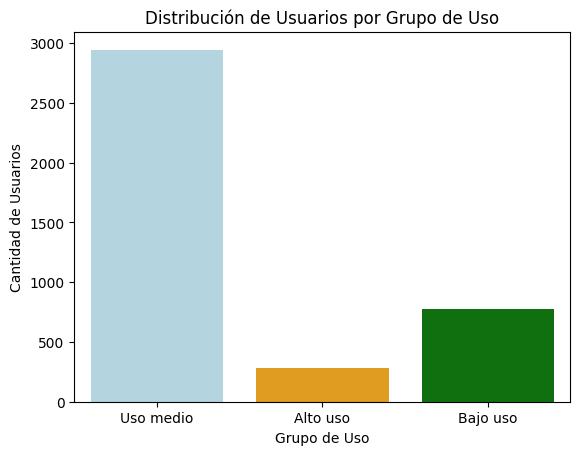

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', palette=['lightblue', 'orange', 'green'])
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

/tmp/ipykernel_5178/3861334363.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=user_profile, x='grupo_edad', palette=['lightcoral', 'skyblue', 'gold'])


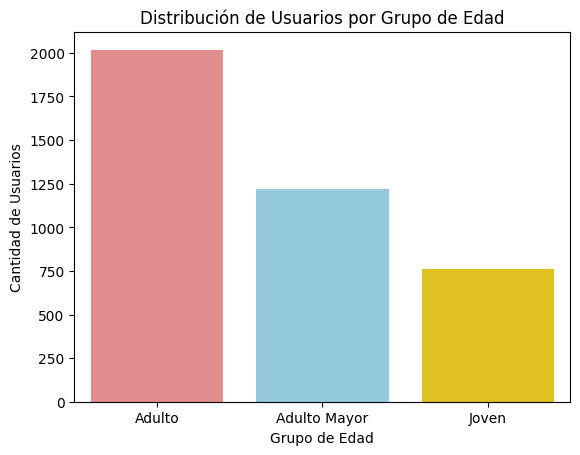

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', palette=['lightcoral', 'skyblue', 'gold'])
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Durante el proceso de análisis se identificaron diversos problemas de calidad en los datos:

° Valores centinela en edad: se detectaron 40 usuarios con edad igual a -999, equivalente al 1% del dataset.
° Valores centinela en ciudad: se encontraron 96 registros con el valor "?", representando el 2.4% de los datos.
° Fechas futuras: se identificaron 40 registros con fechas correspondientes al año 2026, lo que representa el 1% del conjunto de datos.
° Valores nulos estructurales: las variables duration y length contenían valores nulos que, tras el análisis, se determinaron como correctos bajo un patrón MAR (Missing At Random).


🔍 **Segmentos por Edad**
° Joven: menores de 30 años
° Adulto: entre 30 y 59 años
° Adulto mayor: 60 años o más

📊 **Segmentos por Nivel de Uso**
° Bajo uso: usuarios con menos de 5 llamadas y menos de 5 mensajes
° Uso medio: usuarios con menos de 10 llamadas y menos de 10 mensajes
° Alto uso: resto de los usuarios

➡️ Hallazgos principales:

A partir del análisis de segmentación por edad y nivel de uso, se observa una mayor concentración de usuarios mayores de 30 años, especialmente en el rango de 50 a 70 años. Asimismo, destaca que la mayoría de los clientes utiliza el plan “Básico”, probablemente debido a su accesibilidad económica y facilidad de uso.

Por otro lado, únicamente un usuario cuenta con el plan “Premium”, lo que evidencia una baja adopción de este servicio y sugiere la necesidad de analizar las posibles causas, como costos elevados, compatibilidad con dispositivos, beneficios percibidos o limitaciones de accesibilidad.

Respecto al comportamiento de uso, existe un equilibrio entre llamadas y mensajes; sin embargo, se identifica una ligera preferencia por los mensajes. Esto podría explicarse porque los mensajes no generan consumo significativo del plan o cuentan con menos restricciones de uso en comparación con las llamadas.

En términos generales, la preferencia por el plan básico parece estar relacionada con factores como:

1. menor costo,
2. facilidad de acceso,
3. simplicidad en el servicio,
4. cobertura suficiente para las necesidades esenciales de comunicación.


💡 **Recomendaciones**
Se recomienda realizar un análisis más profundo sobre las características y beneficios del plan Premium, con el objetivo de identificar áreas de mejora y aumentar su adopción entre los clientes.

Entre las principales acciones sugeridas destacan:

Evaluar la compatibilidad del plan Premium con los dispositivos móviles utilizados por los clientes.
Analizar las necesidades reales de comunicación, conectividad y accesibilidad de los usuarios.
Diseñar un plan intermedio que combine beneficios del plan Básico con algunas ventajas del Premium, permitiendo medir el nivel de aceptación del mercado.
Revisar la estructura de costos y beneficios del plan Premium para hacerlo más atractivo y competitivo.
Implementar pruebas piloto o rediseños temporales del plan Premium, integrando la sencillez y accesibilidad del plan Básico junto con mejoras en conectividad, alcance y calidad del servicio.

Asimismo, se recomienda que la implementación de estos cambios se realice de manera gradual, en un periodo aproximado de 6 a 12 meses, permitiendo una transición controlada y una evaluación continua de resultados.

La estrategia podría dividirse en las siguientes etapas:

1. Diagnóstico y análisis (1-2 meses): evaluación de necesidades de los clientes, compatibilidad de dispositivos, costos y beneficios de los planes actuales.
2. Diseño del nuevo plan (1 mes): definición de características, precios y beneficios del plan intermedio o rediseñado.
3. Pruebas piloto (2-3 meses): lanzamiento limitado para medir aceptación, satisfacción y comportamiento de uso de los clientes.
4. Ajustes estratégicos (1 mes): optimización del plan con base en la retroalimentación obtenida durante la fase piloto.
5. Implementación general (1-2 meses): despliegue comercial acompañado de campañas de difusión y soporte técnico.
6. Monitoreo continuo: seguimiento del desempeño del nuevo plan, satisfacción de clientes y rentabilidad del servicio.

Se considera especialmente importante la fase piloto, ya que permitirá reducir riesgos operativos y financieros antes de realizar una implementación masiva. Además, debido a que la mayoría de los usuarios pertenece a segmentos adultos y adultos mayores, una transición progresiva facilitaría la adaptación de los clientes a las nuevas características de los planes.

Finalmente, adaptar los servicios a las condiciones económicas y tecnológicas de los usuarios podría incrementar la satisfacción del cliente, fortalecer la competitividad de la compañía y favorecer la captación de nuevos usuarios.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`